# nb25 — Fisher information about source position across JAISP stages

**Question.** The scientific parameter is $\theta=(x,y)$, the true position of a point source.
How much information about $\theta$ survives at each stage of the pipeline?

$$D_{\rm pixels} \;\to\; z_{\rm stems} \;\to\; z_{\rm streams} \;\to\; z_{\rm fused} \;\to\; (\hat x,\hat y)$$

Each arrow is a compression. Fisher information $F(\theta)$ gives lossy compression a
measurable meaning for a *specific* question: $F_{\rm after} < F_{\rm before}$ means the
representation discarded information relevant to that question. If
$F_{\rm bottleneck}\approx F_{\rm pixels}$ for astrometry, the latent is a near-lossless
compression *with respect to source position*, even though it is grossly lossy overall.

**Method** (pilot: 1 held-out patch-25 tile, peak SNR 10, 16 injected sources):

- **Stochasticity convention.** The network is deterministic, so Fisher is undefined without
  a noise model. We fix the real tile as the (noisy but frozen) *scene*, inject a Gaussian
  point source at known sub-pixel $\theta$ in all 10 bands (nb09 convention), and add **fresh
  synthetic noise** $n\sim\mathcal N(0,\,\mathrm{var\ map})$ per realization. The fresh noise
  is the stochasticity at every stage, including the analytic pixel CRB, so the comparison is
  internally consistent. Per-source scatter across realizations counts only fresh-noise
  sensitivity; the frozen scene noise shows up as a per-source *bias*, reported separately.
- **Stage A, pixels (exact, analytic).** $F=\sum_{\rm pix}(\partial m/\partial\theta)^2/\sigma^2_{\rm pix}$
  for the injected Gaussian. No Monte Carlo. This is also the data-processing-inequality
  ceiling: no downstream stage may exceed it — a built-in sanity check.
- **Stage B, latents (Monte-Carlo lower bounds).** For each stage we take the same local
  window the head sees (17×17 VIS stem, 5×5 fused grid), at a **fixed** query position.
  Jacobian $J=\partial\langle z\rangle/\partial\theta$ from central differences at
  $\pm\delta$ (25 mas), with common random numbers across shifts. The windows are
  6.4k–18.5k dimensional, so $J^\top C^{-1}J$ with a raw sample covariance would be badly
  biased **high** (undersampled $C^{-1}$) — exactly the failure mode that would fake a
  "lossless compression" headline. Instead we project $z$ onto span$(J)$ (optionally + top
  noise PCs), estimate the 2×2 (or small-$p$) covariance with a Hartlap correction, and get a
  guaranteed **lower bound** on the stage's Fisher information (equivalently an *upper*
  bound on its $\sigma_{\rm eq}=F^{-1/2}$).
- **Stage C, estimators.** Classical VIS centroid and the position head, run on every center
  realization: empirical scatter → $1/\sigma^2$ (a lower bound on $F$ reachable by an actual
  estimator). The head's predicted $\sigma$ is shown for context only — nb24 found it needs a
  global calibration factor $\alpha$, and it reflects total noise, not fresh-only.

**Stages compared.** Analytic pixels (Rubin-only / Euclid-only / VIS-only / all-band), the
pre-fusion per-stream latents (`stream_maps['rubin'|'euclid']`, 0.4″ grid), the fused
bottleneck, the native 0.1″ VIS stem, and the head. The stream-vs-fused comparison asks the
architecture question directly: *how much astrometric information does the joint
representation move across instruments, and how much requires the retained high-resolution
VIS stem?*


In [1]:
import sys, json, time
from pathlib import Path

def find_repo_root(s=None):
    s = (s or Path.cwd()).resolve()
    for c in [s, *s.parents]:
        if (c/'models').exists() and (c/'data').exists():
            return c
    raise FileNotFoundError('repo root')

REPO = find_repo_root()
for p in (REPO/'models', REPO, REPO/'models'/'astrometry2'):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import numpy as np
import torch
import matplotlib.pyplot as plt
from astropy.wcs import WCS
from scipy.spatial import cKDTree

from astrometry2.latent_position_head import (
    load_latent_position_head, extract_local_windows, vis_px_to_bottleneck_px)
from astrometry2.source_matching import safe_header_from_card_string
from astrometry2.dataset import (
    build_full_context_detector_inputs, refine_centroids_psf_fit,
    local_vis_pixel_to_sky_matrix)

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
OUT = REPO/'io'/'_nb25_outputs'
OUT.mkdir(exist_ok=True)

FOUNDATION = REPO/'models/checkpoints/jaisp_v10_q1_long/checkpoint_best.pt'
HEAD_CKPT  = REPO/'models/checkpoints/latent_position_q1_vissep_patchval25/best.pt'  # patch-disjoint head

CFG = dict(
    tile_index = 0,      # which sorted patch-25 stem
    n_src      = 16,     # injected sources sharing every forward pass
    snr        = 10.0,   # per-band peak SNR of the injected Gaussian (nb09 convention)
    delta_px   = 0.25,   # finite-difference shift in VIS px (= 25 mas)
    n_center   = 128,    # noise realizations at theta0 (covariance + estimator scatter)
    n_jac      = 8,      # realizations averaged per +/-delta point (common random numbers)
    n_jac2     = 4,      # realizations per +/-2*delta point (linearity check)
    seed       = 20260811,
)
SIGMA_PX = {'VIS': 2.5/2.355, 'NISP': 2.5/2.355, 'RUBIN': 3.0/2.355}
RUBIN_BANDS = ['u','g','r','i','z','y']
NISP_BANDS  = ['Y','J','H']
VIS_MAS, RUBIN_MAS = 100.0, 200.0   # mas per native pixel
print(DEVICE)

cuda:0


In [2]:
# ---- frozen encoder + patch-disjoint position head, and the pilot tile ----
ck = torch.load(HEAD_CKPT, map_location='cpu', weights_only=False)
hcfg = ck.get('config', {})
fe, head = load_latent_position_head(
    str(FOUNDATION), device=DEVICE,
    bottleneck_window=hcfg.get('bottleneck_window', 5) or 5,
    stem_window=hcfg.get('stem_window', 17) or 17)
head.load_state_dict(ck['head_state_dict'])
head.eval()

rdir, edir = REPO/'data/rubin_tiles_patch25', REPO/'data/euclid_tiles_all_q1'
stem = sorted(p.name[:-4] for p in rdir.glob('tile_*.npz'))[CFG['tile_index']]
rdata = dict(np.load(rdir/f'{stem}.npz', allow_pickle=True))
edata = dict(np.load(edir/f'{stem}_euclid.npz', allow_pickle=True))
vwcs = WCS(safe_header_from_card_string(edata['wcs_VIS'].item()))
rwcs = WCS(rdata['wcs_hdr'].item())

base_images, tile_rms, vis_hw = build_full_context_detector_inputs(
    edata, rdata['img'], rubin_var=rdata.get('var'))
H, W = vis_hw
rms_t = {b: torch.from_numpy(r[None, None].copy()).float().to(DEVICE)
         for b, r in tile_rms.items()}

BAND_INFO = {}   # band -> (wcs, mas per px, injected gaussian sigma in px)
for b in ['VIS'] + NISP_BANDS:
    w = vwcs if b == 'VIS' else WCS(safe_header_from_card_string(edata[f'wcs_{b}'].item()))
    BAND_INFO[f'euclid_{b}'] = (w, VIS_MAS, SIGMA_PX['VIS' if b == 'VIS' else 'NISP'])
for b in RUBIN_BANDS:
    BAND_INFO[f'rubin_{b}'] = (rwcs, RUBIN_MAS, SIGMA_PX['RUBIN'])

print(stem, 'head epoch', ck.get('epoch'))
print({b: base_images[b].shape for b in list(base_images)[:3]}, '...')

JAISPFoundationV10: 9.2M trainable parameters
  stem_ch=64, hidden_ch=256, fused_scale=0.40"/px
  stream_depths={'rubin': 1, 'euclid': 2}
  rubin_concat=True  (symmetric concat fusion)
  loss_type=charbonnier  charbonnier_eps=0.001  core_l2_weight=0.2  core_info_thr=0.5
  rubin decoder channels: [128]
  euclid decoder channels: [256, 128]
Loaded v10 foundation (fused_scale=0.4, rubin_concat=True, loss=charbonnier, core_l2=0.2) from /home/shemmati/Work/Projects/JAISP/models/checkpoints/jaisp_v10_q1_long/checkpoint_best.pt
  bottleneck_window=5  (physical coverage: 2.0" at 0.40"/px)
LatentPositionHead: 0.69M trainable, 7.3M frozen encoder  (v10 foundation)


tile_x00000_y00000_tract5063_patch_25 head epoch 30
{'rubin_u': (512, 512), 'rubin_g': (512, 512), 'rubin_r': (512, 512)} ...


In [3]:
# ---- injection sites: random sub-pixel, away from real sources and tile edges ----
LAB = torch.load(REPO/'data/detection_labels/centernet_q1_790_vissep_thresh03.pt',
                 map_location='cpu', weights_only=False)
LAB = LAB['labels'] if 'labels' in LAB else LAB
rng = np.random.default_rng(CFG['seed'])
if stem in LAB:
    ent = LAB[stem]
    xy_norm = np.asarray(ent[0] if isinstance(ent, tuple) else ent, dtype=np.float32)
    existing = np.stack([xy_norm[:, 0]*(W-1), xy_norm[:, 1]*(H-1)], axis=1)
else:
    existing = np.zeros((0, 2), np.float32)
tree = cKDTree(existing) if len(existing) else None

pts = []
while len(pts) < CFG['n_src']:
    x, y = rng.uniform(120, W-120), rng.uniform(120, H-120)
    if tree is not None and np.isfinite(tree.query([[x, y]], distance_upper_bound=25.0)[0][0]):
        continue
    if pts and np.min(np.hypot(*(np.asarray(pts) - [x, y]).T)) < 80:
        continue
    pts.append([x, y])
pts = np.asarray(pts, np.float32)
ra0, dec0 = vwcs.pixel_to_world_values(pts[:, 0], pts[:, 1])
pix2sky = np.stack([local_vis_pixel_to_sky_matrix(vwcs, p) for p in pts]).astype(np.float32)
print(f'{len(pts)} injection sites on {stem}')

16 injection sites on tile_x00000_y00000_tract5063_patch_25


## Stage A — analytic pixel-level Fisher (exact)

For the injected Gaussian $m(\theta)$ in white noise with the tile's local variance,
$F_{xx}=\sum_{\rm pix}(\partial m/\partial x)^2/\sigma^2_{\rm pix}$, evaluated at the true
sub-pixel phase. For a fixed *peak* SNR this is nearly independent of the PSF width (wider
PSF spreads the gradient over more pixels), and combining bands is just summing Fisher in
sky (mas) units. These numbers are exact under the noise convention and form the hard
ceiling for every downstream stage.

per-axis pixel CRB at peak SNR 10 (median over sources):
  VIS only       : sigma_CRB =   7.98 mas
  Euclid 4-band  : sigma_CRB =   3.99 mas
  Rubin 6-band   : sigma_CRB =   6.51 mas
  all 10 bands   : sigma_CRB =   3.40 mas


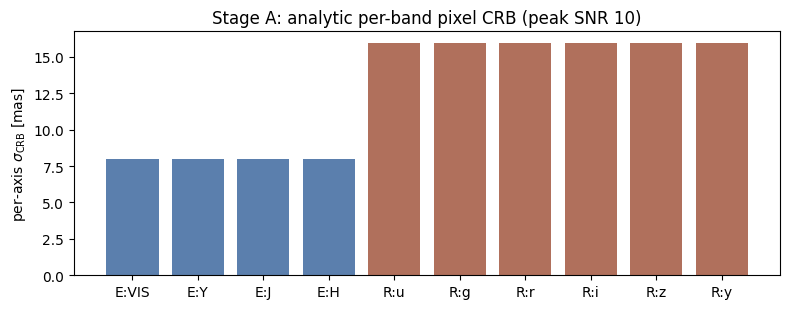

In [4]:
def pixel_fisher_band(amp, x, y, sigma, var_local):
    # per-axis Fisher (band px^-2) of an isotropic Gaussian, peak amp, sampled at pixel centres
    r = int(max(8, np.ceil(5*sigma)))
    yy, xx = np.mgrid[-r:r+1, -r:r+1].astype(np.float64)
    xx += (x - round(x)); yy += (y - round(y))          # keep the true sub-pixel phase
    g = np.exp(-0.5*(xx**2 + yy**2)/sigma**2)
    dmdx = amp * (xx/sigma**2) * g
    return float((dmdx**2).sum() / var_local)

def local_rms(rms_img, x, y):
    xi = int(np.clip(round(float(x)), 0, rms_img.shape[1]-1))
    yi = int(np.clip(round(float(y)), 0, rms_img.shape[0]-1))
    v = float(rms_img[yi, xi])
    return v if np.isfinite(v) and v > 0 else float(np.nanmedian(rms_img))

F_pix = {}   # band -> [n_src] per-axis Fisher in mas^-2
for band, (bw, scale_mas, sig) in BAND_INFO.items():
    bx, by = bw.world_to_pixel_values(ra0, dec0)
    F = np.zeros(len(pts))
    for k in range(len(pts)):
        r = local_rms(tile_rms[band], bx[k], by[k])
        F[k] = pixel_fisher_band(CFG['snr']*r, bx[k], by[k], sig, r*r) / scale_mas**2
    F_pix[band] = F

F_pix_vis = F_pix['euclid_VIS']
F_pix_euc = np.sum([F_pix[b] for b in F_pix if b.startswith('euclid')], axis=0)
F_pix_rub = np.sum([F_pix[b] for b in F_pix if b.startswith('rubin')], axis=0)
F_pix_all = np.sum([F_pix[b] for b in F_pix], axis=0)

print(f'per-axis pixel CRB at peak SNR {CFG["snr"]:.0f} (median over sources):')
for name, F in [('VIS only', F_pix_vis), ('Euclid 4-band', F_pix_euc),
                ('Rubin 6-band', F_pix_rub), ('all 10 bands', F_pix_all)]:
    print(f'  {name:15s}: sigma_CRB = {np.median(1/np.sqrt(F)):6.2f} mas')

fig, ax = plt.subplots(figsize=(8, 3.2))
order = list(BAND_INFO)
med = [np.median(1/np.sqrt(F_pix[b])) for b in order]
ax.bar(range(len(order)), med,
       color=['#5b7fad' if b.startswith('euclid') else '#b0705c' for b in order])
ax.set_xticks(range(len(order)))
ax.set_xticklabels([b.replace('euclid_', 'E:').replace('rubin_', 'R:') for b in order])
ax.set_ylabel(r'per-axis $\sigma_{\rm CRB}$ [mas]')
ax.set_title(f'Stage A: analytic per-band pixel CRB (peak SNR {CFG["snr"]:.0f})')
plt.tight_layout(); plt.show()

## Stage B setup — injection deltas and the realization engine

One forward pass serves all 16 sources. For each of the 9 shift points (center, $\pm\delta$,
$\pm2\delta$ along each axis) we pre-build the noiseless injection image per band (each band
gets the shifted *sky* position through its own WCS, sub-pixel, nb09 convention). A
realization = base scene + injection delta + fresh noise, encoded once; we then read out
fixed-position local windows from four representations. The query windows do **not** follow
the source — the information must live in how the window *content* responds to the shift.

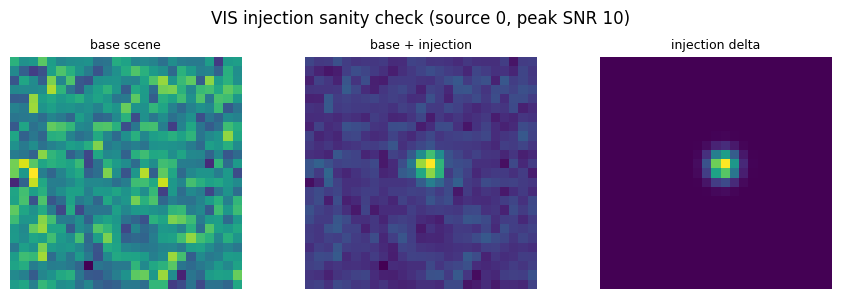

In [5]:
SHIFTS = {
    'c':   (0.0, 0.0),
    '+x':  (+CFG['delta_px'], 0.0), '-x':  (-CFG['delta_px'], 0.0),
    '+y':  (0.0, +CFG['delta_px']), '-y':  (0.0, -CFG['delta_px']),
    '+2x': (+2*CFG['delta_px'], 0.0), '-2x': (-2*CFG['delta_px'], 0.0),
    '+2y': (0.0, +2*CFG['delta_px']), '-2y': (0.0, -2*CFG['delta_px']),
}

def inject_gauss(img, x, y, sigma, amp):   # nb09 convention, float sub-pixel centre
    Hh, Ww = img.shape
    r = int(max(6, np.ceil(4*sigma)))
    x0, x1 = max(0, int(x)-r), min(Ww, int(x)+r+1)
    y0, y1 = max(0, int(y)-r), min(Hh, int(y)+r+1)
    yy, xx = np.mgrid[y0:y1, x0:x1]
    img[y0:y1, x0:x1] += (amp*np.exp(-0.5*(((xx-x)/sigma)**2 + ((yy-y)/sigma)**2))).astype(img.dtype)

DELTAS = {}
for tag, (dx, dy) in SHIFTS.items():
    ra, dec = vwcs.pixel_to_world_values(pts[:, 0]+dx, pts[:, 1]+dy)
    d = {}
    for band, (bw, scale_mas, sig) in BAND_INFO.items():
        bx, by = bw.world_to_pixel_values(ra, dec)
        delta = np.zeros_like(base_images[band])
        for k in range(len(pts)):
            amp = CFG['snr']*local_rms(tile_rms[band], bx[k], by[k])
            inject_gauss(delta, float(bx[k]), float(by[k]), sig, amp)
        d[band] = delta
    DELTAS[tag] = d

k0 = 0
x0, y0 = pts[k0]
sl = np.s_[int(y0)-12:int(y0)+13, int(x0)-12:int(x0)+13]
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for ax, (ttl, im) in zip(axes, [
        ('base scene', base_images['euclid_VIS'][sl]),
        ('base + injection', (base_images['euclid_VIS']+DELTAS['c']['euclid_VIS'])[sl]),
        ('injection delta', DELTAS['c']['euclid_VIS'][sl])]):
    ax.imshow(im, origin='lower'); ax.set_title(ttl, fontsize=9); ax.axis('off')
plt.suptitle(f'VIS injection sanity check (source 0, peak SNR {CFG["snr"]:.0f})')
plt.tight_layout(); plt.show()

In [6]:
pos_vis_t = torch.from_numpy(pts).float().to(DEVICE)
pos_bn_t = None                       # set on first encode (needs fused_hw)
STAGE_WIN = {'vis_stem': 17, 'stream_euclid': 5, 'stream_rubin': 5, 'bottleneck': 5}
pix2sky_t = torch.from_numpy(pix2sky).to(DEVICE)
pix2sky_inv = np.linalg.inv(pix2sky)

@torch.no_grad()
def encode_realization(shift_tag, noise_seed, want_head=False):
    r = np.random.default_rng(noise_seed)
    imgs, img_t = {}, {}
    for band in base_images:
        img = (base_images[band] + DELTAS[shift_tag][band]
               + r.standard_normal(base_images[band].shape).astype(np.float32)*tile_rms[band])
        imgs[band] = img
        img_t[band] = torch.from_numpy(img[None, None]).to(DEVICE)
    enc = fe.encoder(img_t, rms_t)
    vis_stem = fe.vis_stem(img_t['euclid_VIS'], rms_t['euclid_VIS'])
    fused_hw = enc['fused_hw']
    global pos_bn_t
    if pos_bn_t is None:
        pos_bn_t = vis_px_to_bottleneck_px(pos_vis_t, 0.1, 0.4, fused_hw, vis_hw)
    maps = {'vis_stem': vis_stem, 'bottleneck': enc['bottleneck'],
            'stream_euclid': enc['stream_maps']['euclid'],
            'stream_rubin': enc['stream_maps']['rubin']}
    out = {s: extract_local_windows(m, pos_vis_t if s == 'vis_stem' else pos_bn_t,
                                    STAGE_WIN[s]).reshape(len(pts), -1).float().cpu().numpy()
           for s, m in maps.items()}
    extras = {}
    if want_head:
        h = head(enc['bottleneck'], vis_stem, pos_vis_t, pix2sky_t, fused_hw, vis_hw)
        pred_px = np.einsum('nij,nj->ni', pix2sky_inv, h['pred_offset_arcsec'].cpu().numpy())
        extras['head_xy'] = pts + pred_px
        extras['sigma_pred'] = np.exp(h['log_sigma'].cpu().numpy())
        cxy, _, _ = refine_centroids_psf_fit(imgs['euclid_VIS'], pts.copy(),
                                             radius=3, fwhm_guess=2.5)
        extras['classical_xy'] = np.asarray(cxy, np.float32)
    return out, extras

t0 = time.time()
_ = encode_realization('c', 0, want_head=True)
dt = time.time() - t0
n_total = CFG['n_center'] + 4*CFG['n_jac'] + 4*CFG['n_jac2']
print(f'{dt:.2f} s per realization -> ~{n_total*dt/60:.1f} min for {n_total} encodes')

5.66 s per realization -> ~16.6 min for 176 encodes


In [7]:
# ---- main Monte-Carlo loop ----
JAC_TAGS, JAC2_TAGS = ['+x', '-x', '+y', '-y'], ['+2x', '-2x', '+2y', '-2y']
zc_list, HEADXY, CLSXY, SIGP = [], [], [], []
t0 = time.time()
for i in range(CFG['n_center']):
    out, ex = encode_realization('c', CFG['seed']+i, want_head=True)
    zc_list.append(out)
    HEADXY.append(ex['head_xy']); CLSXY.append(ex['classical_xy']); SIGP.append(ex['sigma_pred'])
    if (i+1) % 16 == 0:
        print(f'  center {i+1}/{CFG["n_center"]}  ({(time.time()-t0)/60:.1f} min)', flush=True)

# common random numbers: the SAME noise seeds across all shift tags, so the
# finite difference cancels the noise instead of fighting it
zs_list = {t: [] for t in JAC_TAGS + JAC2_TAGS}
for t_ in JAC_TAGS:
    for i in range(CFG['n_jac']):
        zs_list[t_].append(encode_realization(t_, CFG['seed']+200000+i)[0])
for t_ in JAC2_TAGS:
    for i in range(CFG['n_jac2']):
        zs_list[t_].append(encode_realization(t_, CFG['seed']+200000+i)[0])
print(f'total {(time.time()-t0)/60:.1f} min')

STAGES = list(STAGE_WIN)
Zc = {s: np.stack([r[s] for r in zc_list]) for s in STAGES}    # [N, n_src, D]
Zs = {t_: {s: np.stack([r[s] for r in zs_list[t_]]) for s in STAGES} for t_ in zs_list}
HEADXY, CLSXY, SIGP = np.stack(HEADXY), np.stack(CLSXY), np.stack(SIGP)
del zc_list, zs_list
print({s: Zc[s].shape for s in STAGES})

  center 16/128  (0.4 min)


  center 32/128  (0.9 min)


  center 48/128  (1.3 min)


  center 64/128  (1.7 min)


  center 80/128  (2.2 min)


  center 96/128  (2.6 min)


  center 112/128  (3.1 min)


  center 128/128  (3.5 min)


total 4.8 min


{'vis_stem': (128, 16, 18496), 'stream_euclid': (128, 16, 6400), 'stream_rubin': (128, 16, 6400), 'bottleneck': (128, 16, 6400)}


## Jacobians and linearity

$J = \partial\langle z\rangle/\partial\theta$ from central differences. The local-Gaussian
Fisher approximation needs the response to be linear over the probe scale; comparing the
$\pm\delta$ and $\pm2\delta$ slopes checks that 25 mas is inside the linear regime.

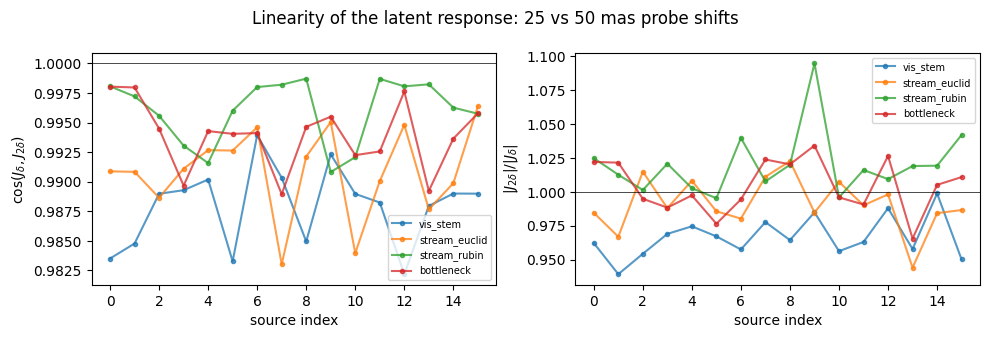

In [8]:
d = CFG['delta_px']
J, J2 = {}, {}
for s in STAGES:
    J[s] = np.stack([(Zs['+x'][s]-Zs['-x'][s]).mean(0)/(2*d),
                     (Zs['+y'][s]-Zs['-y'][s]).mean(0)/(2*d)], axis=-1)   # [n_src, D, 2]
    J2[s] = np.stack([(Zs['+2x'][s]-Zs['-2x'][s]).mean(0)/(4*d),
                      (Zs['+2y'][s]-Zs['-2y'][s]).mean(0)/(4*d)], axis=-1)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
for s in STAGES:
    cos, ratio = [], []
    for k in range(len(pts)):
        c_, r_ = [], []
        for a in (0, 1):
            n1, n2 = np.linalg.norm(J[s][k, :, a]), np.linalg.norm(J2[s][k, :, a])
            c_.append(np.dot(J[s][k, :, a], J2[s][k, :, a])/(n1*n2 + 1e-12))
            r_.append(n2/(n1 + 1e-12))
        cos.append(np.mean(c_)); ratio.append(np.mean(r_))
    axes[0].plot(cos, 'o-', ms=3, alpha=.75, label=s)
    axes[1].plot(ratio, 'o-', ms=3, alpha=.75, label=s)
axes[0].set_ylabel(r'cos$(J_\delta, J_{2\delta})$'); axes[0].axhline(1, c='k', lw=.5)
axes[1].set_ylabel(r'$|J_{2\delta}|/|J_\delta|$'); axes[1].axhline(1, c='k', lw=.5)
for ax in axes:
    ax.set_xlabel('source index'); ax.legend(fontsize=7)
plt.suptitle('Linearity of the latent response: 25 vs 50 mas probe shifts')
plt.tight_layout(); plt.show()

## Latent Fisher lower bounds

Project each stage's window onto span$(J)$ (optionally augmented with the top noise PCs),
estimate the small-$p$ covariance with a Hartlap correction, and form
$F = M^\top \hat C^{-1} M$ with $M = Q^\top J$. Any projection can only *lose* information,
so these are lower bounds on the stage's Fisher; equivalently the plotted
$\sigma_{\rm eq}=\sqrt[4]{\det F^{-1}}$ is an **upper** bound on the stage's effective
positional error. Convergence in $N$ and in the number of extra PCA modes tells us whether
the bound is tight or starved.

vis_stem      : median sigma_eq <=  14.35 mas  (pixel all-band floor 3.40)
stream_euclid : median sigma_eq <=  30.08 mas  (pixel all-band floor 3.40)
stream_rubin  : median sigma_eq <= 103.17 mas  (pixel all-band floor 3.40)
bottleneck    : median sigma_eq <=  42.74 mas  (pixel all-band floor 3.40)


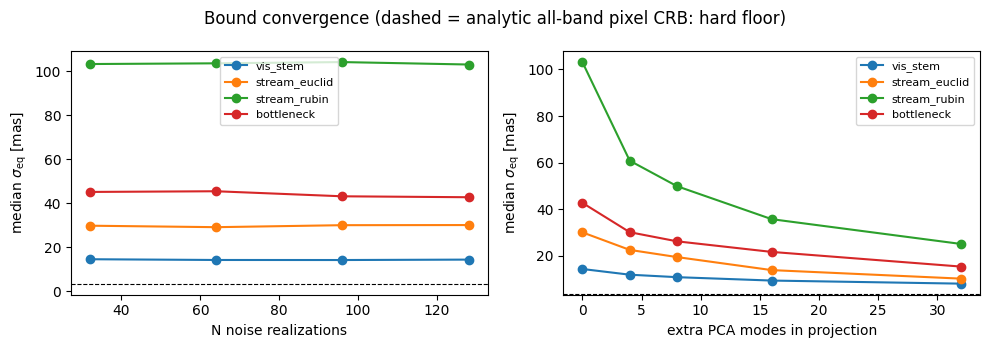

In [9]:
def fisher_proj(X, Jk, n_pc=0):
    # X [N, D] realizations at theta0; Jk [D, 2]. Returns 2x2 Fisher in VIS px^-2.
    Xc = X - X.mean(0)
    N = X.shape[0]
    B = Jk
    if n_pc:
        _, _, Vt = np.linalg.svd(Xc, full_matrices=False)
        B = np.concatenate([B, Vt[:n_pc].T], axis=1)
    Q, _ = np.linalg.qr(B)
    p = Q.shape[1]
    if N <= p + 3:
        return np.full((2, 2), np.nan)
    T = Xc @ Q
    C = np.cov(T, rowvar=False)
    hartlap = (N - p - 2)/(N - 1)
    M = Q.T @ Jk
    return M.T @ (hartlap*np.linalg.inv(np.atleast_2d(C))) @ M

def sigma_eq_mas(F_px2):
    # geometric-mean per-axis sigma [mas] from a 2x2 Fisher in VIS px^-2
    F_px2 = np.asarray(F_px2, np.float64)
    if not np.all(np.isfinite(F_px2)):
        return np.nan
    cov = np.linalg.inv(F_px2)
    return float(np.linalg.det(cov)**0.25)*VIS_MAS

F_lat = {s: np.stack([fisher_proj(Zc[s][:, k], J[s][k]) for k in range(len(pts))])
         for s in STAGES}
sig_lat = {s: np.array([sigma_eq_mas(F_lat[s][k]) for k in range(len(pts))]) for s in STAGES}
for s in STAGES:
    print(f'{s:14s}: median sigma_eq <= {np.nanmedian(sig_lat[s]):6.2f} mas  '
          f'(pixel all-band floor {np.median(1/np.sqrt(F_pix_all)):.2f})')

Ns = [32, 64, 96, CFG['n_center']]
ks = [0, 4, 8, 16, 32]
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for s in STAGES:
    axes[0].plot(Ns, [np.nanmedian([sigma_eq_mas(fisher_proj(Zc[s][:n, k], J[s][k]))
                                    for k in range(len(pts))]) for n in Ns], 'o-', label=s)
    axes[1].plot(ks, [np.nanmedian([sigma_eq_mas(fisher_proj(Zc[s][:, k], J[s][k], n_pc=kk))
                                    for k in range(len(pts))]) for kk in ks], 'o-', label=s)
axes[0].set_xlabel('N noise realizations'); axes[1].set_xlabel('extra PCA modes in projection')
for ax in axes:
    ax.set_ylabel(r'median $\sigma_{\rm eq}$ [mas]')
    ax.axhline(np.median(1/np.sqrt(F_pix_all)), ls='--', c='k', lw=.8)
    ax.legend(fontsize=8)
plt.suptitle('Bound convergence (dashed = analytic all-band pixel CRB: hard floor)')
plt.tight_layout(); plt.show()

In [10]:
# ---- Stage C: estimator-level information ----
sig_cls_emp = np.sqrt(np.nanvar(CLSXY, axis=0).mean(-1))*VIS_MAS   # per-axis rms, mas
sig_head_emp = np.sqrt(HEADXY.var(axis=0).mean(-1))*VIS_MAS
bias_cls = np.hypot(*((np.nanmean(CLSXY, 0)-pts)*VIS_MAS).T)
bias_head = np.hypot(*((HEADXY.mean(0)-pts)*VIS_MAS).T)
sig_pred = np.median(SIGP, axis=0)*1000.0                          # arcsec -> mas

print('median over sources (mas):')
print(f'  classical VIS centroid: scatter {np.nanmedian(sig_cls_emp):6.2f}, '
      f'frozen-scene bias {np.nanmedian(bias_cls):6.2f}')
print(f'  position head:          scatter {np.median(sig_head_emp):6.2f}, '
      f'frozen-scene bias {np.median(bias_head):6.2f}, predicted sigma {np.median(sig_pred):6.2f}')

median over sources (mas):
  classical VIS centroid: scatter   8.06, frozen-scene bias   9.38
  position head:          scatter   7.69, frozen-scene bias   8.77, predicted sigma   4.42


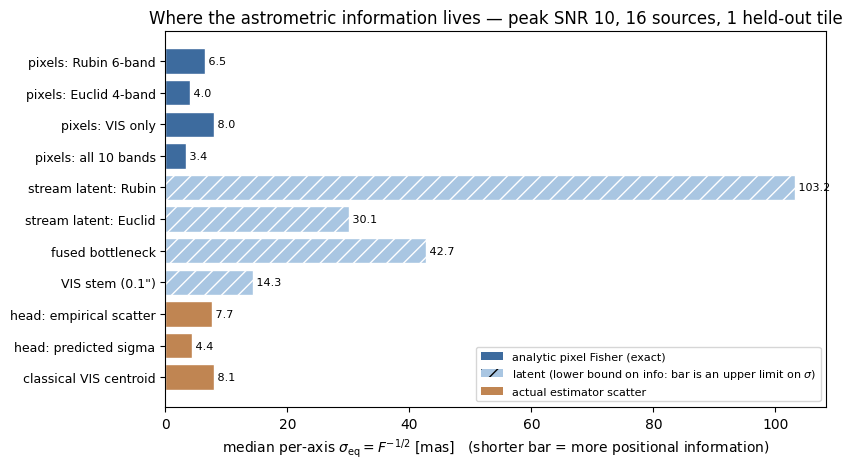

saved /home/shemmati/Work/Projects/JAISP/io/_nb25_outputs/fisher_pilot_summary.json


In [11]:
# ---- the information waterfall ----
rows = [
    ('pixels: Rubin 6-band',    np.median(1/np.sqrt(F_pix_rub)),        'exact'),
    ('pixels: Euclid 4-band',   np.median(1/np.sqrt(F_pix_euc)),        'exact'),
    ('pixels: VIS only',        np.median(1/np.sqrt(F_pix_vis)),        'exact'),
    ('pixels: all 10 bands',    np.median(1/np.sqrt(F_pix_all)),        'exact'),
    ('stream latent: Rubin',    np.nanmedian(sig_lat['stream_rubin']),  'bound'),
    ('stream latent: Euclid',   np.nanmedian(sig_lat['stream_euclid']), 'bound'),
    ('fused bottleneck',        np.nanmedian(sig_lat['bottleneck']),    'bound'),
    ('VIS stem (0.1")',         np.nanmedian(sig_lat['vis_stem']),      'bound'),
    ('head: empirical scatter', np.median(sig_head_emp),                'estimator'),
    ('head: predicted sigma',   np.median(sig_pred),                    'estimator'),
    ('classical VIS centroid',  np.nanmedian(sig_cls_emp),              'estimator'),
]
colors = {'exact': '#3d6b9e', 'bound': '#a9c6e2', 'estimator': '#c08552'}
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ypos = np.arange(len(rows))[::-1]
for yi, (name, v, kind) in zip(ypos, rows):
    ax.barh(yi, v, color=colors[kind], hatch='//' if kind == 'bound' else None,
            edgecolor='white')
    if np.isfinite(v):
        ax.text(v, yi, f' {v:.1f}', va='center', fontsize=8)
ax.set_yticks(ypos); ax.set_yticklabels([r[0] for r in rows], fontsize=9)
ax.set_xlabel(r'median per-axis $\sigma_{\rm eq}=F^{-1/2}$ [mas]   (shorter bar = more positional information)')
ax.set_title(f'Where the astrometric information lives — peak SNR {CFG["snr"]:.0f}, '
             f'{len(pts)} sources, 1 held-out tile')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(fc=colors['exact'], label='analytic pixel Fisher (exact)'),
                   Patch(fc=colors['bound'], hatch='//', label=r'latent (lower bound on info: bar is an upper limit on $\sigma$)'),
                   Patch(fc=colors['estimator'], label='actual estimator scatter')],
          fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig(OUT/'fisher_waterfall_snr10.png', dpi=150)
plt.show()

summary = dict(config=CFG, tile=stem,
               rows=[(n, float(v), k) for n, v, k in rows],
               sig_lat={s: [float(v) for v in sig_lat[s]] for s in STAGES})
json.dump(summary, open(OUT/'fisher_pilot_summary.json', 'w'), indent=1)
np.savez(OUT/'fisher_pilot_arrays.npz', pts=pts,
         sig_cls_emp=sig_cls_emp, sig_head_emp=sig_head_emp, sig_pred=sig_pred,
         bias_cls=bias_cls, bias_head=bias_head,
         F_pix_vis=F_pix_vis, F_pix_euc=F_pix_euc, F_pix_rub=F_pix_rub, F_pix_all=F_pix_all,
         **{f'F_lat_{s}': F_lat[s] for s in STAGES})
print('saved', OUT/'fisher_pilot_summary.json')

## Is the multi-band information new and constraining?

The all-band CRB of 3.4 mas only means something if the non-VIS bands contribute
*independent* constraints on the same $(x,y)$ — independent errors add information;
correlated errors are partly the same information (or the same mistake) counted twice.
Three tests, all on the same noise realizations used above:

1. **Joint 10-band fit.** One shared sky position, fitted by weighted $\chi^2$ to all ten
   stamps simultaneously (per-band amplitude and background profiled out analytically, the
   per-band WCS entering through a local affine map). If its scatter reaches the all-band
   CRB, the information is drainable by an actual estimator.
2. **Inter-band error correlations.** Fit each band alone on every realization and
   correlate the position errors between bands. Near-zero off-diagonals = independent
   information. (On real sky this is exactly the matrix that shared WCS/PSF systematics
   would light up.)
3. **The addition law.** Inverse-variance-combine the ten single-band fits and compare
   against the $1/\sqrt{\sum_b 1/\sigma_b^2}$ prediction.


In [12]:
from scipy.optimize import least_squares

R_STAMP = {b: (9 if b.startswith('euclid') else 6) for b in BAND_INFO}

# local affine map d(band px)/d(VIS px) and band-frame truth per band/source
A_MAP, BPX0 = {}, {}
for band, (bw, scale_mas, sig) in BAND_INFO.items():
    bx0, by0 = bw.world_to_pixel_values(ra0, dec0)
    BPX0[band] = np.stack([bx0, by0], axis=1)
    A = np.zeros((len(pts), 2, 2))
    for a in range(2):
        e = np.eye(2)[a]
        ra_e, dec_e = vwcs.pixel_to_world_values(pts[:, 0]+e[0], pts[:, 1]+e[1])
        bx_e, by_e = bw.world_to_pixel_values(ra_e, dec_e)
        A[:, 0, a] = bx_e - bx0
        A[:, 1, a] = by_e - by0
    A_MAP[band] = A

def band_stamp(img, band, k):
    R = R_STAMP[band]
    cx, cy = BPX0[band][k]
    x0, y0 = int(round(cx))-R, int(round(cy))-R
    return img[y0:y0+2*R+1, x0:x0+2*R+1], x0, y0

FIT_CTX = {}
for band in BAND_INFO:
    for k in range(len(pts)):
        st_rms, x0, y0 = band_stamp(tile_rms[band], band, k)
        yy, xx = np.mgrid[y0:y0+st_rms.shape[0], x0:x0+st_rms.shape[1]]
        FIT_CTX[band, k] = (xx.astype(np.float64), yy.astype(np.float64),
                            (1.0/np.clip(st_rms, 1e-12, None)**2).astype(np.float64))

def chi_residuals(dxy, stamps, bands, k):
    # shared (dx,dy) in VIS px; per-band amplitude + constant profiled out analytically
    res = []
    for band, st in zip(bands, stamps):
        xx, yy, w = FIT_CTX[band, k]
        sig = BAND_INFO[band][2]
        c = BPX0[band][k] + A_MAP[band][k] @ dxy
        g = np.exp(-0.5*(((xx-c[0])/sig)**2 + ((yy-c[1])/sig)**2))
        M = np.stack([g.ravel(), np.ones(g.size)], axis=1)
        Wv = w.ravel()
        coef = np.linalg.solve(M.T @ (M*Wv[:, None]), M.T @ (Wv*st.ravel()))
        res.append((st.ravel() - M @ coef)*np.sqrt(Wv))
    return np.concatenate(res)

def fit_position(stamps, bands, k):
    try:
        sol = least_squares(chi_residuals, [0.0, 0.0], args=(stamps, bands, k),
                            bounds=(-3, 3), diff_step=0.05)
        return sol.x
    except Exception:
        return np.array([np.nan, np.nan])

In [13]:
# same noise seeds (and per-band draw order) as the encode loop -> paired realizations
ALL_BANDS = list(BAND_INFO)
xy_joint = np.zeros((CFG['n_center'], len(pts), 2))
xy_band = np.zeros((CFG['n_center'], len(ALL_BANDS), len(pts), 2))
t0 = time.time()
for i in range(CFG['n_center']):
    r = np.random.default_rng(CFG['seed']+i)
    imgs = {}
    for band in base_images:
        imgs[band] = (base_images[band] + DELTAS['c'][band]
                      + r.standard_normal(base_images[band].shape).astype(np.float32)*tile_rms[band])
    for k in range(len(pts)):
        stamps = [band_stamp(imgs[b], b, k)[0].astype(np.float64) for b in ALL_BANDS]
        xy_joint[i, k] = fit_position(stamps, ALL_BANDS, k)
        for bi, b in enumerate(ALL_BANDS):
            xy_band[i, bi, k] = fit_position([stamps[bi]], [b], k)
    if (i+1) % 32 == 0:
        print(f'  fits {i+1}/{CFG["n_center"]}  ({(time.time()-t0)/60:.1f} min)', flush=True)
print(f'fits done in {(time.time()-t0)/60:.1f} min')

  fits 32/128  (0.2 min)


  fits 64/128  (0.4 min)


  fits 96/128  (0.7 min)


  fits 128/128  (0.9 min)


fits done in 0.9 min


median over sources (per-axis, mas):
  VIS single-band fit    :   7.82   (VIS pixel CRB 7.98)
  joint 10-band fit      :   3.42   (all-band pixel CRB 3.40)
  IV combo of 10 fits    :   3.40   (addition-law prediction 3.41)
  inter-band error correlations: median |off-diag| = 0.014, max = 0.061


/home/shemmati/.local/lib/python3.9/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/shemmati/.local/lib/python3.9/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


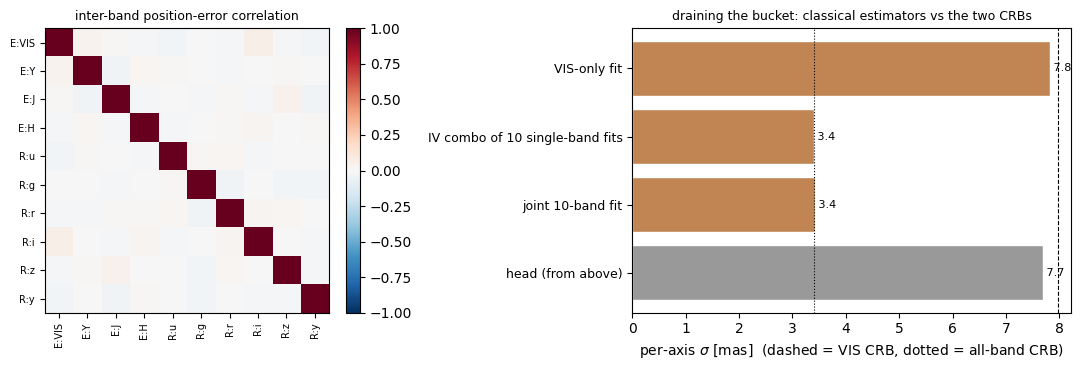

In [14]:
# (dx,dy) are offsets from truth in VIS px, so the error IS the fitted value
sig_joint = np.sqrt(np.nanvar(xy_joint, axis=0).mean(-1))*VIS_MAS            # [n_src]
sig_band_fit = np.sqrt(np.nanvar(xy_band, axis=0).mean(-1))*VIS_MAS          # [n_band, n_src]
vis_idx = ALL_BANDS.index('euclid_VIS')

# test 3: inverse-variance combination of the 10 single-band fits vs the addition law
w = 1.0/np.nanvar(xy_band, axis=0).mean(-1)                                  # [n_band, n_src]
combo = np.nansum(xy_band*w[None, :, :, None], axis=1)/np.nansum(w, axis=0)[None, :, None]
sig_combo = np.sqrt(np.nanvar(combo, axis=0).mean(-1))*VIS_MAS
sig_pred_add = 1.0/np.sqrt(np.nansum(1.0/sig_band_fit**2, axis=0))           # addition law

print('median over sources (per-axis, mas):')
print(f'  VIS single-band fit    : {np.nanmedian(sig_band_fit[vis_idx]):6.2f}   (VIS pixel CRB {np.median(1/np.sqrt(F_pix_vis)):.2f})')
print(f'  joint 10-band fit      : {np.nanmedian(sig_joint):6.2f}   (all-band pixel CRB {np.median(1/np.sqrt(F_pix_all)):.2f})')
print(f'  IV combo of 10 fits    : {np.nanmedian(sig_combo):6.2f}   (addition-law prediction {np.nanmedian(sig_pred_add):.2f})')

# test 2: inter-band error correlation matrix (median over sources and axes)
nb_ = len(ALL_BANDS)
C_acc = []
for k in range(len(pts)):
    for a in (0, 1):
        E = xy_band[:, :, k, a]                                              # [N, n_band]
        ok = np.isfinite(E).all(1)
        if ok.sum() > 8:
            C_acc.append(np.corrcoef(E[ok].T))
C_med = np.nanmedian(np.stack(C_acc), axis=0)
off = C_med[~np.eye(nb_, dtype=bool)]
print(f'  inter-band error correlations: median |off-diag| = {np.median(np.abs(off)):.3f}, max = {np.abs(off).max():.3f}')

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), gridspec_kw={'width_ratios': [1, 1.3]})
im = axes[0].imshow(C_med, vmin=-1, vmax=1, cmap='RdBu_r')
short = [b.replace('euclid_', 'E:').replace('rubin_', 'R:') for b in ALL_BANDS]
axes[0].set_xticks(range(nb_)); axes[0].set_xticklabels(short, rotation=90, fontsize=7)
axes[0].set_yticks(range(nb_)); axes[0].set_yticklabels(short, fontsize=7)
axes[0].set_title('inter-band position-error correlation', fontsize=9)
plt.colorbar(im, ax=axes[0], fraction=0.046)

bars = [('VIS-only fit', np.nanmedian(sig_band_fit[vis_idx]), '#c08552'),
        ('IV combo of 10 single-band fits', np.nanmedian(sig_combo), '#c08552'),
        ('joint 10-band fit', np.nanmedian(sig_joint), '#c08552'),
        ('head (from above)', np.median(sig_head_emp), '#999999')]
yp = np.arange(len(bars))[::-1]
for yi, (n, v, c) in zip(yp, bars):
    axes[1].barh(yi, v, color=c, edgecolor='white')
    axes[1].text(v, yi, f' {v:.1f}', va='center', fontsize=8)
axes[1].set_yticks(yp); axes[1].set_yticklabels([b[0] for b in bars], fontsize=9)
axes[1].axvline(np.median(1/np.sqrt(F_pix_vis)), ls='--', c='k', lw=.8)
axes[1].axvline(np.median(1/np.sqrt(F_pix_all)), ls=':', c='k', lw=.8)
axes[1].set_xlabel(r'per-axis $\sigma$ [mas]  (dashed = VIS CRB, dotted = all-band CRB)')
axes[1].set_title('draining the bucket: classical estimators vs the two CRBs', fontsize=9)
plt.tight_layout()
plt.savefig(OUT/'jointfit_independence_snr10.png', dpi=150)
plt.show()

np.savez(OUT/'jointfit_arrays.npz', xy_joint=xy_joint, xy_band=xy_band,
         bands=np.array(ALL_BANDS), C_med=C_med,
         sig_joint=sig_joint, sig_band_fit=sig_band_fit, sig_combo=sig_combo)

## Findings (pilot: tile_x00000_y00000_tract5063_patch_25, peak SNR 10, 16 sources, N=128)

**Sanity checks pass.** Every latent bound sits above the all-band pixel CRB (the
data-processing floor); the latent response is linear over the probe scale
(cos$(J_\delta,J_{2\delta})\geq0.98$, norm ratios within $\pm7\%$); bounds are stable in $N$.

**Pixel anchors (exact, per-axis):** VIS 7.98 mas, Euclid 4-band 3.99, Rubin 6-band 6.51,
all 10 bands 3.40 mas.

**The head saturates the VIS information and stops there.** Head empirical scatter
7.69 mas $\approx$ classical VIS centroid 8.06 $\approx$ VIS-only pixel CRB 7.98. This is
the Fisher-language version of the paper's "adds no precision beyond what VIS itself
provides" — and it quantifies the remaining headroom: the all-band CRB of 3.40 mas means a
further $\times(7.69/3.40)^2\approx5$ in Fisher information exists in the pixels but is not
exploited by the current estimator chain. The head's predicted $\sigma$ (median 4.42 mas)
is overconfident by $\alpha\approx1.7$ against its own fresh-noise scatter, consistent with
nb24's bright-end $\alpha$.

**Latent stages (lower bounds on information; $\sigma$ values are upper limits).**
J-span projection alone gives VIS stem $\leq$14.3, Euclid stream $\leq$30.1, fused
bottleneck $\leq$42.7, Rubin stream $\leq$103 mas. But the PCA-augmentation curve is still
falling at +32 modes (roughly 7–8 / 10 / 15 / 25 mas respectively), so these bounds are
*starved*, not evidence of loss: the raw projection onto $J$ is not noise-whitened, and a
better low-dim statistic keeps finding more information. Two provisional readings, to be
firmed up with a whitened estimator:

- The **VIS stem looks near-lossless for astrometry** — its +32-mode bound essentially
  reaches the VIS pixel CRB.
- The **0.4″ fused bottleneck retains position information at the $\lesssim$15 mas level**
  and the Rubin stream alone at $\lesssim$25 mas despite the coarse grid — but the head's
  actual precision is clearly carried by the VIS-stem path, matching the architecture's
  design intent.

**The bucket information is new, constraining, and drainable (joint-fit section).**
Three tests on the same paired noise realizations:

- *Independence:* the 10×10 inter-band position-error correlation matrix is empty —
  median $|$off-diag$|$ = 0.014, max 0.061. Each band's measurement is a genuinely fresh
  constraint (on this synthetic setup, by construction; on real sky this same matrix is
  where shared WCS/PSF systematics would appear).
- *Additivity:* inverse-variance combining the 10 single-band fits gives 3.40 mas vs the
  addition-law prediction of 3.41 mas.
- *Reachability:* the joint 10-band $\chi^2$ fit achieves **3.42 mas vs the 3.40 mas
  all-band CRB** (and the VIS-only fit gives 7.82 vs its 7.98 CRB — the fitter is
  efficient). A classical estimator fully drains the bucket; the head (7.7 mas) currently
  does not. So the gap is an estimator/architecture limitation (head reads only the fused
  bottleneck + VIS stem), not a property of the data.

**Caveats / next steps**
- Single tile, single SNR, 16 sources: extend to an SNR sweep (5–30) and a handful of
  patch-25 tiles before believing any ordering to better than ~20%.
- Replace the J-span bound with a properly whitened one: GLS in a larger PC space with
  Hartlap-corrected covariance, or a small linear decoder trained on realizations (its
  test-set variance is also a valid information lower bound). The PCA curve says this will
  tighten every latent bar substantially.
- Per-band stems beyond VIS (`band_stem_features`) drop straight into the same engine —
  the per-instrument version of the waterfall.
- The same machinery with $\theta$ = flux (scale the injection amplitude instead of
  shifting it) gives the photometric-information waterfall — one new `DELTAS` block,
  nothing else changes.
